# Bevezető

Ebben a projektben egy használt autó árbecslő rendszert építettem egy körülbelül 420 ezer soros  adathalmazon.

A célom:
- legyen egy árintervallumom, mert a marketplace adatok bizonytalanok: alkudozás van, hiányos a felszereltség, a motor részletei sokszor a szövegben vannak, és sok a zaj.

A folyamatban végigmentem az adatmegértésen, tisztításon, feature engineeringen, baseline modelleken, majd végül egy boosting modellen és quantile regresszión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
cars = pd.read_csv('vehicles.csv')
cars.shape

(426880, 26)

In [3]:
cars.head(3)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN


In [4]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

## Adathalmaz áttekintés

Itt látszik a sorok száma és az oszlopok típusa. Marketplace adatnál tipikus, hogy sok kategóriás mező van, és vannak hiányzó értékek is. A nem szükséges oszlopokat törlöm, majd
a következő lépésben megnézem az ár eloszlását, és eldöntöm, kell-e transzformáció.

In [5]:
cars = cars.drop(columns=['url', 'region', 'region_url', 'VIN', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date'])

In [6]:
cars.price.describe()

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

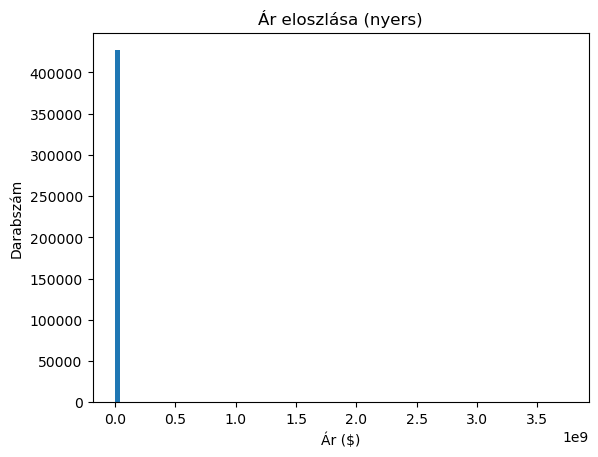

In [7]:
plt.hist(cars.price, bins=100)
plt.xlabel("Ár ($)")
plt.ylabel("Darabszám")
plt.title("Ár eloszlása (nyers)")
plt.show()

## Miért log transform?

A használt autók ára nagyon jobbra ferde: sok olcsó autó és kevés nagyon drága.
Ilyenkor a regressziót stabilabbá teszi, ha log transzformálom az árat.
Én log1p-et használok, mert így a 0 közeli értékekkel is jól működik:

log_price = log(1 + price)

In [8]:
cars["log_price"] = np.log1p(cars["price"])

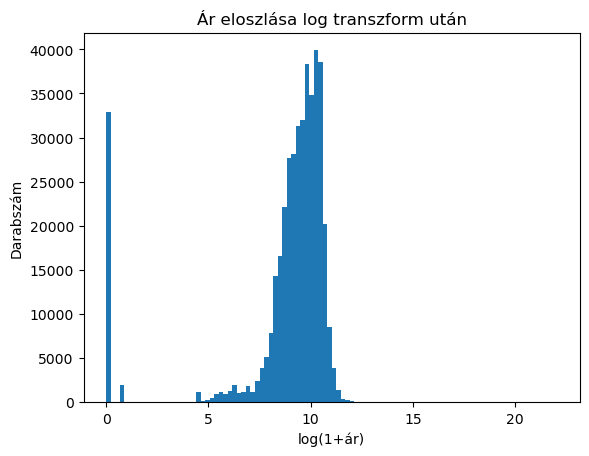

In [9]:
plt.hist(cars["log_price"], bins=100)
plt.xlabel("log(1+ár)")
plt.ylabel("Darabszám")
plt.title("Ár eloszlása log transzform után")
plt.show()

## Alap tisztítás

Marketplace adatoknál tipikus problémák:
- 0 vagy nagyon alacsony ár (nem valódi eladás, hibás rekord, alkatrész)
- extrém magas árak (outlierek / rossz adat)
- extrém futásteljesítmény (hibás odometer)
- hiányzó értékek

In [10]:
cars = cars[cars["price"].notna()]
cars = cars[cars["price"] > 0]
cars = cars[(cars["price"] >= 200) & (cars["price"] <= 1_000_000)]

cars = cars[cars["odometer"].notna()]
cars = cars[(cars["odometer"] >= 0) & (cars["odometer"] <= 600_000)]

cars = cars[cars["year"].notna()]
cars = cars[(cars["year"] >= 1900) & (cars["year"] <= 2022)]

## Feature engineering

A használt autó ár legnagyobb magyarázó tényezői általában:
- életkor (age)
- futásteljesítmény (odometer)

Ezért készítek:
- age = 2022 - year
- log_odometer = log(1 + odometer)

Ezek után a kategóriás változókat one-hot encodinggal kezeljük.

In [11]:
cars["age"] = 2022 - cars["year"]
cars = cars[(cars["age"] >= 0) & (cars["age"] <= 60)]

cars["log_odometer"] = np.log1p(cars["odometer"])

cars["age_sq"] = cars["age"] ** 2
cars["odometer_per_year"] = cars["odometer"] / (cars["age"] + 1)
cars.loc[~np.isfinite(cars["odometer_per_year"]), "odometer_per_year"] = np.nan
cars["log_opy"] = np.log1p(cars["odometer_per_year"]) 

## Title status

A title_status mező (clean, salvage, rebuilt, stb.) jogi/állapotbeli információt hordoz, ami az árat nagyon befolyásolja.
Én a hiányzókat "unknown"-ra állítom, mert a hiányosság önmagában is információ lehet.

Ezen kívül külön megnéztem boxploton, hogy tényleg eltolja-e az árakat – és igen, a salvage és rebuilt láthatóan alacsonyabb árszintet ad.

In [12]:
cars["title_status"] = cars["title_status"].fillna("unknown")

<Figure size 640x480 with 0 Axes>

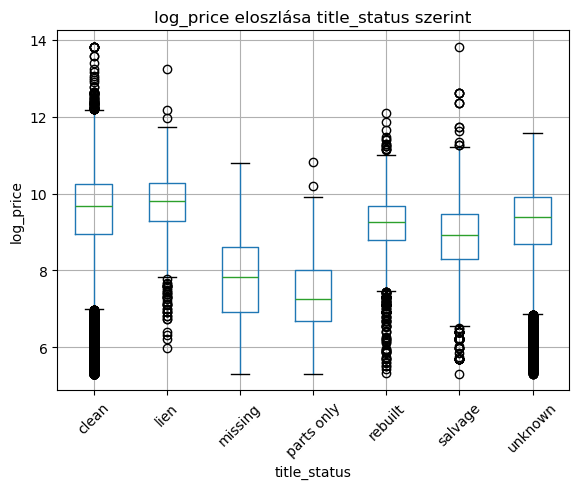

In [13]:
plt.figure()
cars.boxplot(column="log_price", by="title_status", rot=45)
plt.xlabel("title_status")
plt.ylabel("log_price")
plt.title("log_price eloszlása title_status szerint")
plt.suptitle("")
plt.show()

## Modellnevek validálása hivatalos forrás alapján

A "model" mező marketplace adaton erősen zajos:

- felszereltségi szintek
- motorváltozatok
- hibás elgépelések
- nem létező kombinációk
- generikus szavak (pl. "sport", "pickup")

Egy ponton felmerült bennem, hogy ahelyett, hogy manuálisan tisztítanám a modelleket,
érdemes lenne egy hivatalos, strukturált forrásból lekérni a létező gyártó–modell párosokat.

Ez azért fontos, mert:

- csökkenti a zajt
- kizárja a nem létező modelleket
- normalizálja a kategóriákat
- javítja a modell generalizációját
- reprodukálhatóbbá teszi az adatfeldolgozást

In [14]:
validator = pd.read_csv("validator_set.csv")
validator["manufacturer"] = validator["make"].str.lower().str.strip()
validator["model"] = validator["model"].str.lower().str.strip()

In [15]:
cars = cars.dropna(subset=["manufacturer", "model"])

In [16]:
cars["manufacturer"] = cars["manufacturer"].astype(str).str.lower().str.strip()
cars["model"] = cars["model"].astype(str).str.lower().str.strip()

In [17]:
import re

models = sorted(validator["model"].dropna().str.lower().unique(), key=len, reverse=True)
pattern = r"\b(" + "|".join(map(re.escape, models)) + r")\b"

cars["base_model"] = cars["model"].str.lower().str.extract(pattern, expand=False)

In [18]:
cars[["manufacturer", "model", "base_model", "price"]]

,manufacturer,model,base_model,price
27,gmc,sierra 1500 crew cab slt,sierra,33590
28,chevrolet,silverado 1500,silverado,22590
29,chevrolet,silverado 1500 crew,silverado,39590
30,toyota,tundra double cab sr,tundra,30990
31,ford,f-150 xlt,f-150,15000
...,...,...,...,...
426875,nissan,maxima s sedan 4d,maxima,23590
426876,volvo,s60 t5 momentum sedan 4d,s60,30590
426877,cadillac,xt4 sport suv 4d,xt4,34990
426878,lexus,es 350 sedan 4d,es,28990


## Modellezés

Ebben a részben a cél egy olyan modell tanítása, ami a hirdetés jellemzői alapján megbecsüli az autó árát.

A célváltozó `log_price = log(1 + price)`, mert az ár eloszlása erősen jobbra ferde, és a log transzformáció stabilabbá teszi a tanulást.

A modellezést baseline-nal kezdtem:
- Linear Regression: gyors, de tabuláris és nemlineáris összefüggésekre gyenge

Ezután próbáltam:
- Random Forest: erős nemlinearitás, de nagy adaton lassabb lehet

Végül:
- a kategóriás változókat One-Hot Encodinggal alakítom át,
- a numerikus változókat változatlanul átadom,
- a regressziós modell pedig HistGradientBoostingRegressor.

A pontosságot többféleképp mérem:
- RMSE log skálán (stabil összehasonlításhoz),
- MAE log skálán,
- MAE dollárban (érthető üzleti metrika).

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [20]:
categorical = [
    "manufacturer",
    "base_model",
    "condition",
    "fuel",
    "transmission",
    "drive",
    "type",
    "title_status",
]

numeric = ["age", "log_odometer"]

X = cars[categorical + numeric]
y = cars["log_price"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
        ("num", "passthrough", numeric),
    ]
)

In [23]:
hgb_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("regressor", HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1
        ))
    ]
)

In [24]:
hgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [25]:
y_pred = hgb_model.predict(X_test)

In [26]:
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
mae_log = mean_absolute_error(y_test, y_pred)

y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred)
mae_dollar = mean_absolute_error(y_test_price, y_pred_price)

print("HGB RMSE (log):", rmse_log)
print("HGB MAE (log):", mae_log)
print("HGB MAE ($):", round(mae_dollar, 2))

HGB RMSE (log): 0.5809835809176443
HGB MAE (log): 0.3014056079218988
HGB MAE ($): 4300.32


## Árintervallum (Quantile Regression)

Marketplace adatoknál az ár eleve bizonytalan: alkudozás, hiányos infók, eltérő állapot.
Ezért pontbecslés mellett két quantile modellt is tanítok:

- 10% quantile: „alsó becslés”
- 90% quantile: „felső becslés”

Így kapok egy reális ár-sávot.

In [27]:
hgb_lower = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("regressor", HistGradientBoostingRegressor(
            loss="quantile",
            quantile=0.1,
            max_iter=300,
            learning_rate=0.05,
            random_state=42
        ))
    ]
)

hgb_upper = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("regressor", HistGradientBoostingRegressor(
            loss="quantile",
            quantile=0.9,
            max_iter=300,
            learning_rate=0.05,
            random_state=42
        ))
    ]
)

In [28]:
hgb_lower.fit(X_train, y_train)
hgb_upper.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [31]:
sample = pd.DataFrame([{
    "age": 22,
    "log_odometer": np.log1p(220000),
    "manufacturer": "volvo",
    "base_model": "s40",
    "condition": "good",
    "fuel": "gas",
    "transmission": "automatic",
    "drive": "fwd",
    "type": "sedan",
    "title_status": "clean",
}])

In [32]:
low = np.expm1(hgb_lower.predict(sample)[0])
mid = np.expm1(hgb_model.predict(sample)[0])
high = np.expm1(hgb_upper.predict(sample)[0])

print("Árintervallum ($):", round(low, 2), "-", round(high, 2))
print("Pontbecslés ($):", round(mid, 2))

Árintervallum ($): 1288.63 - 5129.91
Pontbecslés ($): 2233.84
